<a href="https://colab.research.google.com/github/ajaypraj/Intrview-preparartion/blob/master/Pandas_basics_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Creating Dataframe**

In [2]:
import pandas as pd
data ={'a':[1,2,3],'b':[4,5,6],'c':[7,8,9]}
df = pd.DataFrame(data, index=[1,2,3])
print(df)

   a  b  c
1  1  4  7
2  2  5  8
3  3  6  9


In [3]:
df1=pd.DataFrame([[1,2,3],
                  [4,5,6],
                  [7,8,9]],
                 columns=['a','b','c'],
                 index=[1,2,3])
df1

,a,b,c
1,1,2,3
2,4,5,6
3,7,8,9


In [4]:
# create dataframe with multiindex
df = pd.DataFrame({'a':[1,2,3],'b':[4,5,6],'c':[7,8,9]}, pd.MultiIndex.from_tuples([('a',1,50),('b',2,60),('c',3,70)],names=['name','id','age']))
df

,,,a,b,c
name,id,age,,,
a,1,50,1,4,7
b,2,60,2,5,8
c,3,70,3,6,9


**Reshaping Data**

In [5]:
#We can chage layout of data by df.concat, df.melt, df.pivot

In [6]:
df1 = pd.DataFrame({'a':[10,20,30],'b':[40,50,60]})
df2=pd.DataFrame({'c':[60,70,80],'d':[90,100,100]})
df3 = pd.concat([df1,df2])  # join along the rows one below other
df4 = pd.concat([df1,df2],axis=1) # join along coluns
df4

,a,b,c,d
0,10,40,60,90
1,20,50,70,100
2,30,60,80,100


In [7]:
# pd.melt convert column data to row data
# Gather columns in to rows
# It converts r<--->c

df =pd.DataFrame({'Name':['A','B','C'], 'Math':[10,20,30], 'Science':[30,40,50]})
df1 = pd.melt(df, id_vars=['Name'],value_vars=['Math', 'Science'], var_name='Subject', value_name='Marks')
df1


,Name,Subject,Marks
0,A,Math,10
1,B,Math,20
2,C,Math,30
3,A,Science,30
4,B,Science,40
5,C,Science,50


In [8]:
# converting Row to columns (pivot)

#DataFrame.pivot(index=None, columns=None, values=None)


df = pd.DataFrame({
    'Date': ['2025-08-01', '2025-08-01', '2025-08-02', '2025-08-02'],
    'City': ['Chennai', 'Delhi', 'Chennai', 'Delhi'],
    'Temperature': [34, 38, 33, 37]
})
print(df)

print(df.pivot(index='Date', columns='City', values='Temperature'))

         Date     City  Temperature
0  2025-08-01  Chennai           34
1  2025-08-01    Delhi           38
2  2025-08-02  Chennai           33
3  2025-08-02    Delhi           37
City        Chennai  Delhi
Date                      
2025-08-01       34     38
2025-08-02       33     37


In [9]:
# sorting of data
df = pd.DataFrame({'a':[10,2,12,13,15,18]})
df2=df.sort_values(by='a', ascending= False)
print(df2)
# rename index
print(df.rename(columns={'a':'AMY'}))



    a
5  18
4  15
3  13
2  12
0  10
1   2
   AMY
0   10
1    2
2   12
3   13
4   15
5   18


In [10]:
# sort index
# moving index to columns and it will reset index to rwo number
df= pd.DataFrame({'a':[1,2],'b':[3,6],'c':[10,20]}, index=['Z','A'])
print(df.reset_index())

  index  a  b   c
0     Z  1  3  10
1     A  2  6  20


In [11]:
# sort indexes
df = pd.DataFrame({'A':[10,20],'B':[15,2]}, index=['Z','A'])
print(df.sort_index(ascending= False))

    A   B
Z  10  15
A  20   2


In [12]:
# dropping columns from dataframe
df= pd.DataFrame({'A':[1,2],'B':[3,4],'C':[3,33]})
df2=df.drop(columns=['B'])
print(df2)

   A   C
0  1   3
1  2  33


In [13]:
# Subset Observation rows
# Exact rows which matches these criteria

df = pd.DataFrame({'A':[1,2,3,4,5,5,6,7,8,9],'B':[10,2,30,4,5,5,6,7,8,90]})
df2 = df[df['A']>=5]
df2
print(df.drop_duplicates()) # it will drop duplicates

print(df.sample(frac = 0.5))
# Prints n largest alue
df.nlargest(2,'B')
# Prints first 5 values
df.head()
# print last 5 values
df.tail()

   A   B
0  1  10
1  2   2
2  3  30
3  4   4
4  5   5
6  6   6
7  7   7
8  8   8
9  9  90
   A   B
7  7   7
8  8   8
3  4   4
9  9  90
4  5   5


,A,B
5,5,5
6,6,6
7,7,7
8,8,8
9,9,90


In [14]:
# Subset variables columns
# select multiple column with specific colums

df = pd.DataFrame({'A':[1,2,3],'B':[4,5,6],'C':[7,8,9]})
df2 = df[['A','C']]
# print(df2)

# print(df['A'])
print(df.A)


0    1
1    2
2    3
Name: A, dtype: int64


In [15]:
# Using query to filter the columns
df= pd.DataFrame({'A':[1,2,3,4,5,5,6,7,8,9],'B':[10,2,30,4,5,5,6,7,8,90]})
df.query('A>5 and B==7')

,A,B
7,7,7


**Subset rows and columns**
Basically these commands will select rows and columns both


In [16]:
# use df.loc and df.iloc to select only rows, only columns or both.

# use df.loc when you wnat to access rows and columns by labels\
# here are some examples df.loc[:,'x2':'x4']  It will select all columns from x2 to x4(inclusive)
# df.loc[df['a']>10, ['b','c']]  selects columns b and c where value of column a is grater than 10
df = pd.DataFrame({'A':[10,20,30],'B':[15,20,25],'C':[25,30,25]})
print(df.loc[df['A']>10,'A':'C'])


# use df.iloc when you want to access rows and columns based on index

print(df.iloc[0,0])


# df.at[] and  df.iat[] by label and index it will select only single value

print(f"Data is printed {df.at[0,'A']}")
print(f"Data is printed {df.iat[0,0]}")

    A   B   C
1  20  20  30
2  30  25  25
10
Data is printed 10
Data is printed 10


In [17]:
df1 = pd.DataFrame({'empid':[100,101,102],'Name':['A','B','C']})
df2 = pd.DataFrame({'empid':[100,101,103],'Dept':['X','Y','Z']})
print(pd.merge(df1, df2, on='empid', how = 'right' ))


df1 = pd.DataFrame({'empid':[100,101,102],'Name':['A','B','C']})
df2 = pd.DataFrame({'empcode':[100,101,103],'Dept':['X','Y','Z']})

df3 = pd.merge(df1, df2, left_on='empid', right_on='empcode', how = 'left' )
df3.drop(columns=['empcode'])

   empid Name Dept
0    100    A    X
1    101    B    Y
2    103  NaN    Z


,empid,Name,Dept
0,100,A,X
1,101,B,Y
2,102,C,NaN


**Summarising data**
methods sum , max, min, apply,  function, df.info, df.count_values


In [18]:
# Summarizing data
df = pd.DataFrame({'A':[1,2,3,4,5,5,6,7,8,9],'B':[10,2,30,4,5,5,6,7,8,90]})
df['A'].value_counts()

,count
A,
5,2
1,1
2,1
3,1
4,1
6,1
7,1
8,1
9,1


In [19]:
df.shape

(10, 2)

In [20]:
df.describe()

,A,B
count,10.000000,10.000000
mean,5.000000,16.700000
std,2.581989,26.936345
min,1.000000,2.000000
25%,3.250000,5.000000
50%,5.000000,6.500000
75%,6.750000,9.500000
max,9.000000,90.000000


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A       10 non-null     int64
 1   B       10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes


In [22]:
df.memory_usage()

,0
Index,132
A,80
B,80


In [23]:
df

,A,B
0,1,10
1,2,2
2,3,30
3,4,4
4,5,5
5,5,5
6,6,6
7,7,7
8,8,8
9,9,90


In [24]:
df = pd.DataFrame({'A':[1,2,3,4,5,5,6,7,8,9],'B':[10,2,30,4,5,5,6,7,8,90]})
df['A'].value_counts()

,count
A,
5,2
1,1
2,1
3,1
4,1
6,1
7,1
8,1
9,1


In [25]:
df['A']


,A
0,1
1,2
2,3
3,4
4,5
5,5
6,6
7,7
8,8
9,9


In [26]:
print(df['A'].median())

5.0


In [27]:
def f(x):
  return 2*x

df['A'].apply(f)

,A
0,2
1,4
2,6
3,8
4,10
5,10
6,12
7,14
8,16
9,18


TypeError: PlotAccessor.scatter() missing 2 required positional arguments: 'x' and 'y'

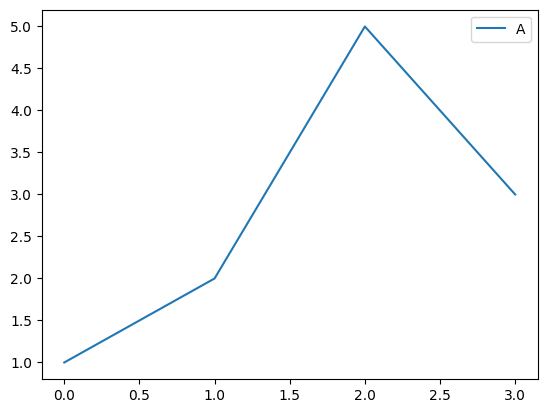

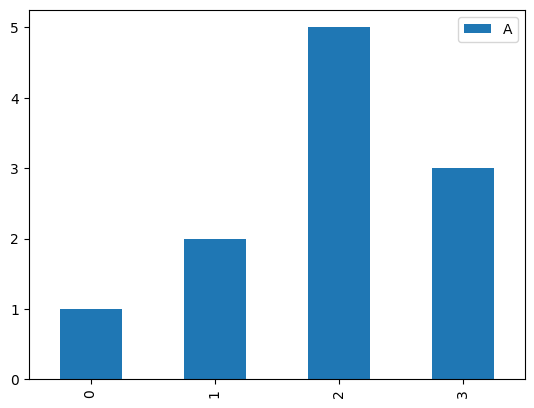

In [36]:
import numpy as np
df = pd.DataFrame({'A': [1, 2, np.nan, 3]})
df = df.fillna(5)
df.plot()  # line plot
df.plot.bar()


